In [2]:
import pymrio
eora_folder = 'eora/'


In [4]:
eora_meta = pymrio.download_eora26(storage_folder=eora_folder, prices=['bp'], email='kasyanova-ka@ranepa.ru', password='Mrio1997')

In [86]:
eora = pymrio.parse_eora26(year=2016, path=eora_folder)

/Users/xena/Library/Python/3.9/lib/python/site-packages/pymrio/tools/ioparser.py:1943: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=1, inplace=True)
/Users/xena/Library/Python/3.9/lib/python/site-packages/pymrio/tools/ioparser.py:1956: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=0, inplace=True)
/Users/xena/Library/Python/3.9/lib/python/site-packages/pymrio/tools/ioparser.py:1943: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=1, inplace=True)
/Users/xena/Library/Python/3.9/lib/python/site-packages/pymrio/tools/ioparser.py:1943: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=1, inplace=Tr

In [90]:

eora.get_regions()



Index(['AFG', 'ALB', 'DZA', 'AND', 'AGO', 'ATG', 'ARG', 'ARM', 'ABW', 'AUS',
       ...
       'TZA', 'USA', 'URY', 'UZB', 'VUT', 'VEN', 'VNM', 'YEM', 'ZMB', 'ZWE'],
      dtype='object', name='region', length=189)

In [91]:

eora.get_sectors()



Index(['Agriculture', 'Fishing', 'Mining and Quarrying', 'Food & Beverages',
       'Textiles and Wearing Apparel', 'Wood and Paper',
       'Petroleum, Chemical and Non-Metallic Mineral Products',
       'Metal Products', 'Electrical and Machinery', 'Transport Equipment',
       'Other Manufacturing', 'Recycling', 'Electricity, Gas and Water',
       'Construction', 'Maintenance and Repair', 'Wholesale Trade',
       'Retail Trade', 'Hotels and Restraurants', 'Transport',
       'Post and Telecommunications',
       'Finacial Intermediation and Business Activities',
       'Public Administration', 'Education, Health and Other Services',
       'Private Households', 'Others', 'Re-export & Re-import'],
      dtype='object', name='sector')

In [92]:
import country_converter as coco

In [93]:
political_reg = {"RUS": "RUS_1", "USA": "USA_2", "UZB": "UZB_3"}

In [94]:
concordance_vec = coco.agg_conc(original_countries="Eora",
                                aggregates=[{'RUS': 'Rus'}, 'OECD', 'EU'],
                                missing_countries='Other',merge_multiple_string=None,as_dataframe='sparse')

/Users/xena/Library/Python/3.9/lib/python/site-packages/country_converter/country_converter.py:780: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'OECD' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[~df[classB].isnull(), classB] = classB


In [95]:
# concordance_vec.iloc[170:,:]

In [96]:
# geographic_reg = {"c1": "geo1", "c2": "geo1", "c3": "geo2", "c4": "geo3", "c5": "geo3"}


In [97]:
# cc = coco.CountryConverter()
# cc.convert(['RUS','BEL'], to='RUS_alone')

In [98]:
# coco.agg_conc(original_countries='Eora',
#                                           aggregates=['OECD'],
#                                           missing_countries='NON_OECD')

In [99]:

eora.aggregate(region_agg = concordance_vec
              )


eora.get_regions()



/Users/xena/Library/Python/3.9/lib/python/site-packages/pymrio/tools/ioutil.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if type(agg_vector[0]) == str:
/Users/xena/Library/Python/3.9/lib/python/site-packages/pymrio/core/mriosystem.py:2309: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if type(region_agg[0]) is str:
/Users/xena/Library/Python/3.9/lib/python/site-packages/pymrio/core/mriosystem.py:890: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  Y_agg = Y.groupby(level="region", axis=1, sort=False).sum()
/Users/xena/Library/Python/3.9/lib/python

Index(['Other', 'OECD', 'EU', 'Unspecified region', 'Rus'], dtype='object', name='region')

In [100]:


eora.calc_all()



/Users/xena/Library/Python/3.9/lib/python/site-packages/pymrio/core/mriosystem.py:890: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  Y_agg = Y.groupby(level="region", axis=1, sort=False).sum()
/Users/xena/Library/Python/3.9/lib/python/site-packages/pymrio/core/mriosystem.py:935: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  F_Y_agg = self.F_Y.groupby(level="region", axis=1, sort=False).sum()
/Users/xena/Library/Python/3.9/lib/python/site-packages/pymrio/core/mriosystem.py:963: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  self.D_cba.groupby(level="region", axis=1, sort=False).sum()
/Users/xena/Library/Python/3.9/lib/python/site-packages/pymrio/core/mriosystem.py:972: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  self.D_pba.groupby(lev

In [120]:
eora.Q.get_index()[2]

('Energy Usage', 'Petroleum')

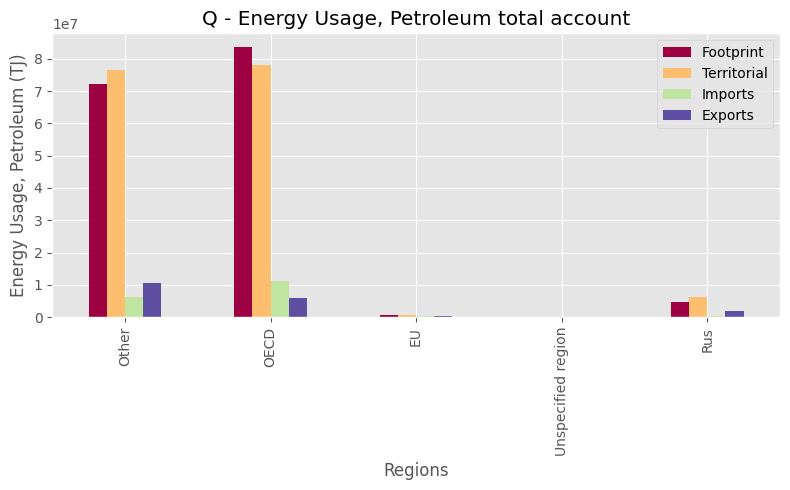

In [121]:
import matplotlib.pyplot as plt
with plt.style.context('ggplot'):
    eora.Q.plot_account(('Energy Usage', 'Petroleum'), figsize=(8,5))
    plt.show()

In [85]:
eora.aggregate(region_agg = coco.agg_conc(original_countries='Eora',
                                          aggregates=['OECD'],
                                          missing_countries='NON_OECD')
              )

/Users/xena/Library/Python/3.9/lib/python/site-packages/country_converter/country_converter.py:780: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'OECD' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[~df[classB].isnull(), classB] = classB
/Users/xena/Library/Python/3.9/lib/python/site-packages/pymrio/tools/ioutil.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if type(agg_vector[0]) == str:
/Users/xena/Library/Python/3.9/lib/python/site-packages/pymrio/core/mriosystem.py:2309: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access 